#### Task 3: Temporal Resampling & Statistical Aggregation

Engineers often need to move between "instantaneous" values and "volumetric" averages. Use Pandas to resample your data.

**Weekly Mean:** Resample the daily data to a Weekly mean.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

In [3]:
#load subsetted data that we saved in the data folder

os.chdir('../')

blackfork = pd.read_csv('data/Blackfork.csv')
greenriver = pd.read_csv('data/Greenriver.csv')
bear_upper = pd.read_csv('data/Bear_Upper.csv')
bear_lower = pd.read_csv('data/Bear_Lower.csv')

greenriver.head() #check that data loaded correctly

,Datetime,USGS_flow
0,2014-01-01,856.71740
1,2014-01-02,857.86456
2,2014-01-03,854.60420
3,2014-01-04,857.01044
4,2014-01-05,857.31250


In [4]:
#aggrerate to weekly means using a loop
#make a list of the dataframes to loop through
dfs = [blackfork, greenriver, bear_upper, bear_lower]
#make an empty list to store the resampled dataframes
resampled_dfs = []
#loop through the dataframes and resample to weekly means
for df in dfs:
    #convert the date column to a datetime object
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    #set the date column as the index
    df.set_index('Datetime', inplace=True)
    #resample to weekly means and store in the resampled_dfs list
    resampled_dfs.append(df.resample('W').mean())

#extract the resampled dataframes from the list
blackfork_weekly = resampled_dfs[0]
greenriver_weekly = resampled_dfs[1]
bear_upper_weekly = resampled_dfs[2]
bear_lower_weekly = resampled_dfs[3]


**Monthly Volumetric:** Resample the data to a Monthly total.

In [5]:
#aggregate to monthly means using a loop
#make an empty list to store the resampled dataframes
resampled_dfs = []
#loop through the dataframes and resample to monthly means
for df in dfs:
    #convert the date column to a datetime object
    # df['Datetime'] = pd.to_datetime(df['Datetime'])
    # #set the date column as the index
    # df.set_index('Datetime', inplace=True)
    #resample to monthly means and store in the resampled_dfs list
    resampled_dfs.append(df.resample('ME').mean())   
#extract the resampled dataframes from the list
blackfork_monthly = resampled_dfs[0]
greenriver_monthly = resampled_dfs[1]
bear_upper_monthly = resampled_dfs[2]
bear_lower_monthly = resampled_dfs[3]


**Visualization:** Create a single multi-paneled figure comparing the three resolutions:

Panel A: Daily (Raw)

Panel B: Weekly Mean

Panel C: Monthly Volume

Panel D: Put the legend here
Ensure that all four streams are on each figure and labeled correctly, including a change of units, if necessary.

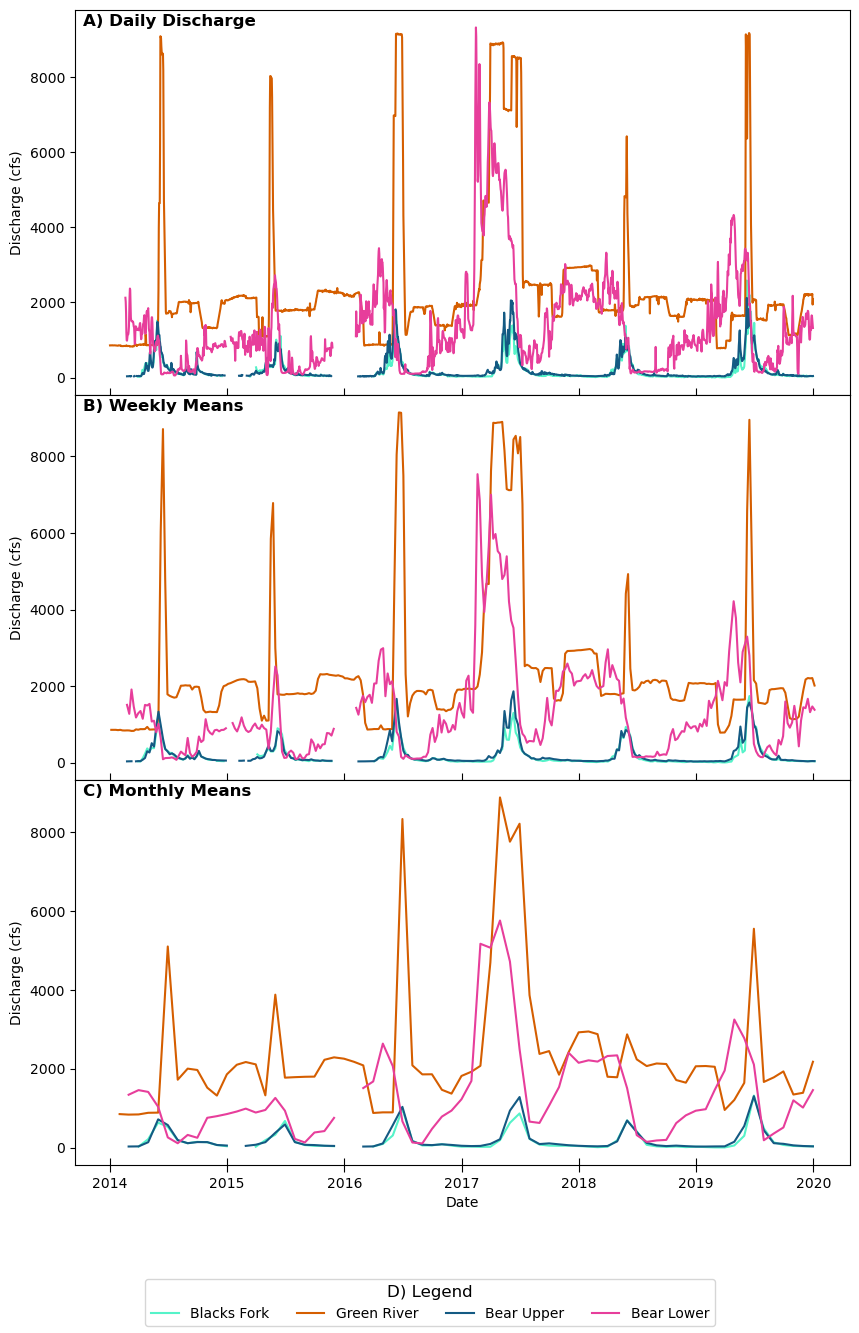

In [6]:
#create a figure with 3 subplots: original data, weekly means, monthly means
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

colors = ["#55F3C9",  # green
          "#D55E00",  # vermillion
          "#145A83",  # bluish
          "#E73E9B"]  # pink

#plot the original data in the first subplot
axs[0].plot(blackfork.index, blackfork['USGS_flow'], label='Blacks Fork', color=colors[0])
axs[0].plot(greenriver.index, greenriver['USGS_flow'], label='Green River', color=colors[1])
axs[0].plot(bear_upper.index, bear_upper['USGS_flow'], label='Bear Upper', color=colors[2])
axs[0].plot(bear_lower.index, bear_lower['USGS_flow'], label='Bear Lower', color=colors[3])
axs[0].set_ylabel('Discharge (cfs)')
#plot the weekly means in the second subplot
axs[1].plot(blackfork_weekly.index, blackfork_weekly['USGS_flow'], color=colors[0])
axs[1].plot(greenriver_weekly.index, greenriver_weekly['USGS_flow'], color=colors[1])
axs[1].plot(bear_upper_weekly.index, bear_upper_weekly['USGS_flow'], color=colors[2])
axs[1].plot(bear_lower_weekly.index, bear_lower_weekly['USGS_flow'], color=colors[3])
axs[1].set_ylabel('Discharge (cfs)')
#plot the monthly means in the third subplot
axs[2].plot(blackfork_monthly.index, blackfork_monthly['USGS_flow'], color=colors[0])
axs[2].plot(greenriver_monthly.index, greenriver_monthly['USGS_flow'], color=colors[1])
axs[2].plot(bear_upper_monthly.index, bear_upper_monthly['USGS_flow'], color=colors[2])
axs[2].plot(bear_lower_monthly.index, bear_lower_monthly['USGS_flow'], color=colors[3])
axs[2].set_ylabel('Discharge (cfs)')
axs[2].set_xlabel('Date')
#remove the x-axis labels from the first two subplots
axs[0].set_xticklabels([])
axs[1].set_xticklabels([])
#format the x-axis labels as years
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs[2].xaxis.set_major_locator(mdates.YearLocator())
#adjust the layout
plt.subplots_adjust(hspace=0)

#adjust x-axis tick marks to be clear on each plot
for ax in axs:
    ax.tick_params(axis='x', # Specify that we are modifying x-axis ticks
                    direction='inout', # Set ticks to point both in and out
                    length=10,
                    )

#add each plot title in the top left corner in the plot area instead of the default title location
titles = ['A) Daily Discharge', 'B) Weekly Means', 'C) Monthly Means']
for ax, title in zip(axs, titles):
    ax.text(0.01, 0.99, title, transform=ax.transAxes, fontsize=12, fontweight='bold', verticalalignment='top')

#add a panel for the legend outside of the plot area on the bottom and label it "D) Legend"
fig.legend(loc='lower center', ncol=4, title='D) Legend', title_fontsize='12', fontsize='10', frameon=True)

#save plot to media folder
plt.savefig('media/aggregation_plot.png', dpi=500)

#show the plot
plt.show()

**Compare and Contrast:** How do the different streams compare (timing, magnitude, other), and how does the temporal resampling highlight similarities and differences between the streams?

The headwater catchments demonstrate similar timing and magnitude. These measurements are on the north slope of the Uintas and relatively close to each other, so their  similarities are not surprising. The rivers further downstream are very different from the headwaters and from each other. Green River is consistently the highest magnitude, even as the data is aggregated into weekly and monthly means. Green River also peaks after the Bear River but the peaks line up with the upper catchments. The Bear River has slow increases in flow every winter, culminating in peak flow that's earlier than our other study sites. The visual of this slow increase over many months is somewhat subdued in the monthly means, which could be a loss of interesting data.  

From the daily data, it seems like 2017 had similar flows between the lower locations. But looking at the monthly data, Green River still had about 2,000 more cfs than the lower Bear River averaged over time. This highlights the sustained peak of the Green River in 2017 and the more typical peak then decrease of the Bear River that brings down its monthly average. 